Workflow DAG:
  [0] Fileset -> Fileset builder=<function get_fileset at 0x7f58132f3ba0>
  [1] SingleMuonAnalysis -> Analysis builder=<function run_analysis at 0x7f5813304040>
  [2] PlottingMuonAnalysis -> Plotting builder=<function plot_results at 0x7f58133040e0>
Edges:
  Fileset -> SingleMuonAnalysis
  SingleMuonAnalysis -> PlottingMuonAnalysis

Run config:
  Strategy:  none
  Executor:  DaskExecutor  workers=None
  Facility:  CoffeaCasaFactory

Executing step 'Fileset' of type 'Fileset' with the user code <function get_fileset at 0x7f58132f3ba0> and user parameters None
Extracted from cache: cache_hist/Fileset/5a06a60c885c55335e8844b58eb1be4393280261c72a18e5f5ff15bf72fa6acd
  -> materialized at cache_hist/Fileset/5a06a60c885c55335e8844b58eb1be4393280261c72a18e5f5ff15bf72fa6acd

Executing step 'SingleMuonAnalysis' of type 'Analysis' with the user code <function run_analysis at 0x7f5813304040> and user parameters None
Extracted from cache: cache_hist/Chunking/a2e1613f18aa6998b4e8aebe74

Output()

loky.process_executor._RemoteTraceback: 
"""
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/site-packages/loky/process_executor.py", line 490, in _process_worker
    r = call_item()
        ^^^^^^^^^^^
  File "/usr/local/lib/python3.12/site-packages/loky/process_executor.py", line 291, in __call__
    return self.fn(*self.args, **self.kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/site-packages/coffea/processor/executor.py", line 1290, in automatic_retries
    raise e
  File "/usr/local/lib/python3.12/site-packages/coffea/processor/executor.py", line 1276, in automatic_retries
    return func(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/site-packages/coffea/processor/executor.py", line 1360, in metadata_fetcher_root
    with uproot.open(
         ^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/site-packages/uproot/reading.py", line 154, in open
    file = ReadOnlyFile(
           ^^^^^^

Failure caught!
------------------------------------
Processing fileset_chunk_1.json
Extracted from cache: cache_hist/ChunkAnalysis/3d4004d7fcbc66e11dc559aac8452664f4c5e43fad5a176e278da9414416d522
Successfully processed!
------------------------------------
Processing fileset_chunk_2.json
Extracted from cache: cache_hist/ChunkAnalysis/c3cd4c60910b371e047099f1a56663634cd5efac950894bb96e9f608c0db96dd
Successfully processed!
------------------------------------
Processing fileset_chunk_3.json
Extracted from cache: cache_hist/ChunkAnalysis/6691120bf57c110100e6dff49184021a25541cdc60b0425181c45bb9bd48350f
Successfully processed!
------------------------------------
Processing fileset_chunk_4.json
Extracted from cache: cache_hist/ChunkAnalysis/fd39e25d469e523905007c70a6f486a4d11fe65ad0ed5677491ad0d70813473f
Successfully processed!
  -> materialized at cache_hist/Analysis/0f9e2f89a32af3ffaf5cab8cd380cb035fbc1acf4b34e5f9d7775eb8ac30491b

Executing step 'PlottingMuonAnalysis' of type 'Plotting' 

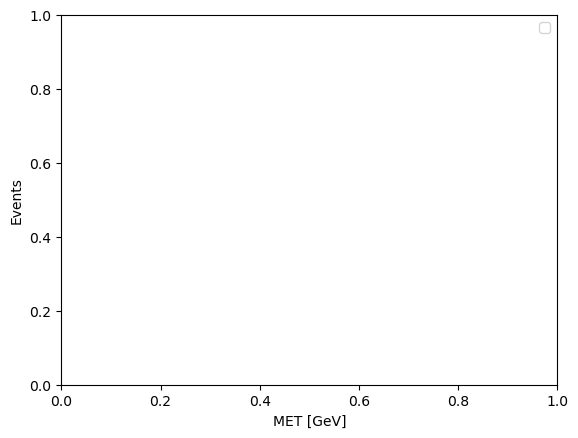

  -> materialized at cache_hist/Plotting/04741fe306aaf3545c48461dc8f0b93351243a2688fb3aa8e6e34d6651cd0233


=== Run Summary ===
  ✓  Fileset                        Fileset
  !  SingleMuonAnalysis             Analysis             4/5 chunks OK
       FAILED fileset_chunk_0.json: Err(OSError('XRootD error: [FATAL] Invalid address'))
  ✓  PlottingMuonAnalysis           Plotting



In [3]:
import histserv
from coffea_workflow import Step, Workflow, Fileset, Analysis, Plotting, RunConfig, ExecutorConfig, run
from coffea_workflow.facilities import CoffeaCasaFactory
from analysis_hist import get_fileset, run_analysis, plot_results, hist_template

# hist_client = histserv.Client(address="[::]:50051") # local
hist_client = histserv.Client(address="histserv.cmsaf-dev.flatiron.hollandhpc.org:8788") # coffea-casa
histserv_connection_info = hist_client.init(hist=hist_template(), token="test").get_connection_info()
# print(histserv_connection_info)


step_fileset = Step(
                    name="Fileset",
                    step_type=Fileset,
                    builder=get_fileset,
                )

step_analysis = Step(
                        name="SingleMuonAnalysis",
                        step_type=Analysis,
                        builder=run_analysis,
                        # add params
                    
                    )

step_plotting = Step(
                    name="PlottingMuonAnalysis",
                    step_type=Plotting,
                    builder=plot_results,
                )

workflow = Workflow()
workflow.add(step_fileset)
workflow.add(step_analysis, depends_on=[step_fileset])
workflow.add(step_plotting, depends_on=[step_analysis])

# To reconnect to an existing histogram on a subsequent run, read
# connection_info from the previous result and pass it here:
#   conn = result["results"]["SingleMuonAnalysis"]["merged"]
#   config = RunConfig(hist_client=hist_client, histserv_connection_info=conn, ...)

config = RunConfig(
                   hist_client=hist_client, 
                   histserv_connection_info=histserv_connection_info, 
                   percentage=20, 
                   cache_dir="cache_hist",
                   facility=CoffeaCasaFactory(),
                   executor_config=ExecutorConfig(
                                        executor_type="DaskExecutor",
                                        worker_packages=("coffea>=2026.7.0",),
                                        worker_files=("analysis_hist.py",),
                                    ),
                  )

result = run(workflow, config)

In [2]:
result

{'paths': {'Fileset': PosixPath('cache_hist/Fileset/5a06a60c885c55335e8844b58eb1be4393280261c72a18e5f5ff15bf72fa6acd'),
  'SingleMuonAnalysis': PosixPath('cache_hist/Analysis/0f9e2f89a32af3ffaf5cab8cd380cb035fbc1acf4b34e5f9d7775eb8ac30491b'),
  'PlottingMuonAnalysis': PosixPath('cache_hist/Plotting/04741fe306aaf3545c48461dc8f0b93351243a2688fb3aa8e6e34d6651cd0233')},
 'results': {'Fileset': {'SingleMu_0': {'files': {'root://eeeeeeospublic.cern.ch//eos/opendata/cms/mc/RunIISummer20UL16NanoAODv9/GluGluHToWWTo2L2Nu_M125_TuneCP5_13TeV_powheg2_JHUGenV714_pythia8/NANOAODSIM/106X_mcRun2_asymptotic_v17-v2/260000/A41320F6-C9F9-574C-8DD2-BD98C200E4EE.root': 'Events',
     'root://eospublic.cern.ch//eos/opendata/cms/mc/RunIISummer20UL16NanoAODv9/GluGluHToWWTo2L2Nu_M125_TuneCP5_13TeV_powheg2_JHUGenV714_pythia8/NANOAODSIM/106X_mcRun2_asymptotic_v17-v2/260000/A7FEFB1C-387F-2B4D-A111-C53CC9371EC7.root': 'Events',
     'root://eospublic.cern.ch//eos/opendata/cms/mc/RunIISummer20UL16NanoAODv9/GluGluHToW